In [20]:
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_DIR = "../data"

bars_seen_train         = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_train.parquet"), engine="fastparquet")
bars_unseen_train       = pd.read_parquet(os.path.join(DATA_DIR, "bars_unseen_train.parquet"), engine="fastparquet")
bars_seen_public_test   = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_public_test.parquet"), engine="fastparquet")
bars_seen_private_test  = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_private_test.parquet"), engine="fastparquet")

headlines_seen_train        = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_train.parquet"), engine="fastparquet")
headlines_unseen_train      = pd.read_parquet(os.path.join(DATA_DIR, "headlines_unseen_train.parquet"), engine="fastparquet")
headlines_seen_public_test  = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_public_test.parquet"), engine="fastparquet")
headlines_seen_private_test = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_private_test.parquet"), engine="fastparquet")

print("bars_seen_train:",         bars_seen_train.shape)
print("bars_unseen_train:",       bars_unseen_train.shape)
print("bars_seen_public_test:",   bars_seen_public_test.shape)
print("bars_seen_private_test:",  bars_seen_private_test.shape)
print("headlines_seen_train:",        headlines_seen_train.shape)
print("headlines_unseen_train:",      headlines_unseen_train.shape)
print("headlines_seen_public_test:",  headlines_seen_public_test.shape)
print("headlines_seen_private_test:", headlines_seen_private_test.shape)

bars_seen_train: (50000, 6)
bars_unseen_train: (50000, 6)
bars_seen_public_test: (500000, 6)
bars_seen_private_test: (500000, 6)
headlines_seen_train: (9740, 3)
headlines_unseen_train: (7631, 3)
headlines_seen_public_test: (99308, 3)
headlines_seen_private_test: (99148, 3)


In [18]:
def plot_session_parameters(
    bars_df,
    headlines_df,
    session_n,
    figsize=(14, 6),
    show_headlines=True,
    rotate_labels=90,
):
    """
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
    """

    # Filter data
    bars = bars_df[bars_df["session"] == session_n].copy()
    news = headlines_df[headlines_df["session"] == session_n].copy()

    if bars.empty:
        print(f"No bars found for session {session_n}")
        return

    # Sort bars
    bars = bars.sort_values("bar_ix")
    news = news.sort_values("bar_ix")

    fig, ax = plt.subplots(figsize=figsize)

    # Plot price line
    ax.plot(
        bars["bar_ix"],
        bars["close"] - bars["open"],
        lw=2,
        label="Close-Open Diff"
    )

    ax.plot(
        bars["bar_ix"],
        bars["high"] - bars["low"],
        lw=2,
        label="High-Low Diff"
    )

    # Vertical lines for headlines
    for _, row in news.iterrows():
        x = row["bar_ix"]

        ax.axvline(
            x=x,
            linestyle="--",
            alpha=0.6,
            linewidth=1
        )

        if show_headlines:
            current_max = (bars["high"] - bars["low"]).max()
            ax.text(
                x,
                current_max,
                row["headline"],
                rotation=rotate_labels,
                va="top",
                ha="right",
                fontsize=8,
                alpha=0.8
            )

    ax.set_title(f"Session {session_n}: Price Movement + Headlines")
    ax.set_xlabel("bar_ix")
    ax.set_ylabel("diff")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

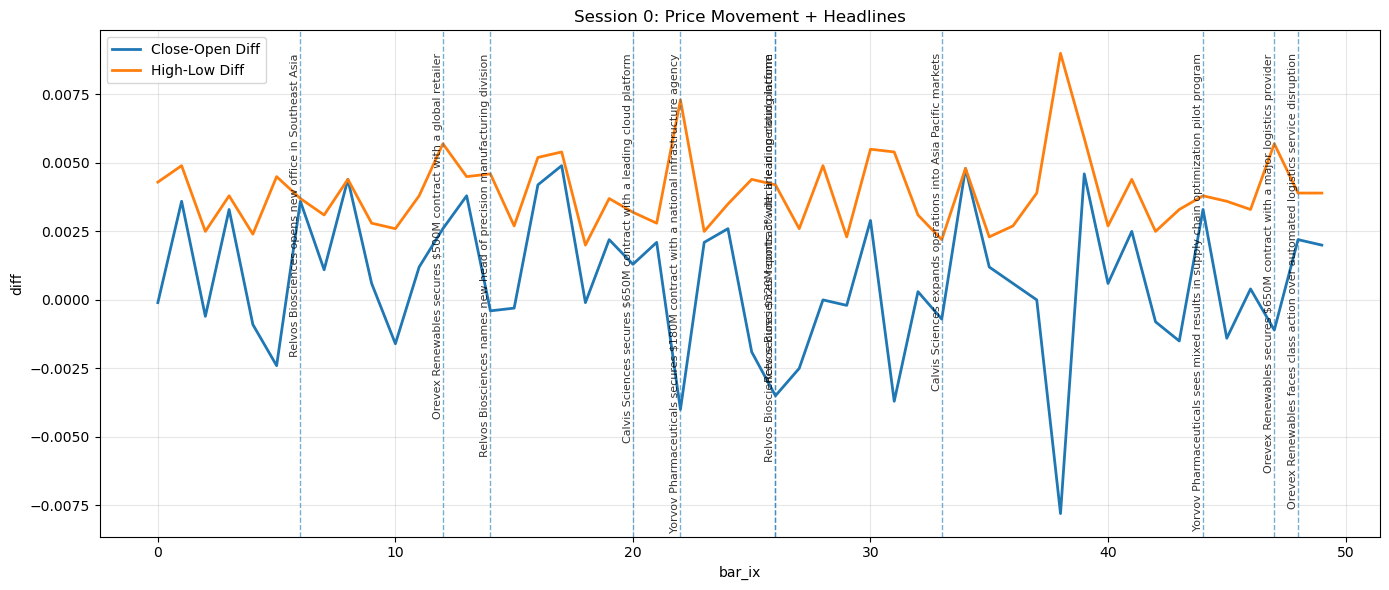

In [19]:
plot_session_parameters(bars_seen_train, headlines_seen_train, 0)

In [23]:
def profile_session_companies(headline_stats, bars_df, session_n, vol_threshold=0.0005):
    """
    Profiles companies in a session based on sentiment-price convergence.
    """
    h_df = pd.read_csv(headline_stats)
    # 1. Filter and Merge
    h_df = headline_stats[headline_stats['session'] == session_n].copy()
    b_df = bars_df[bars_df['session'] == session_n].copy()
    
    if h_df.empty or b_df.empty:
        return "No data found for this session."

    # Merge price action onto headlines using bar_ix
    # We look at the move on the bar the headline hit
    merged = h_df.merge(b_df[['bar_ix', 'open', 'close', 'high', 'low']], on='bar_ix', how='left')
    
    # 2. Calculate Realized Metrics
    # Price Move: (Close - Open) / Open
    merged['realized_return'] = (merged['close'] - merged['open']) / merged['open']
    # Price Volatility: (High - Low) / Open
    merged['realized_vol'] = (merged['high'] - merged['low']) / merged['open']

    # 3. Calculate Profiling Scores
    # Impact Score: Did the news actually trigger a move relative to the sentiment?
    merged['impact_score'] = abs(merged['realized_return']) * abs(merged['polarity_score'])
    
    # Alignment Score: 1 if sentiment & price move same way, -1 if they oppose
    # A 'Defier' is sentiment (+) and return (-) or vice versa.
    merged['alignment'] = np.sign(merged['linear_score'] * merged['realized_return'])

    # 4. Define Profiling Logic
    def get_profile(row):
        is_strong_news = abs(row['polarity_score']) > 0.6
        is_big_move = abs(row['realized_return']) > vol_threshold
        
        if is_strong_news and is_big_move:
            if row['alignment'] > 0:
                return "Primary Catalyst"    # News drove price as expected
            else:
                return "Contrarian Defier"   # Market rejected the news (Strong Signal!)
        elif is_strong_news and not is_big_move:
            return "Priced-In / Ignored"     # Big news, no reaction
        elif not is_strong_news and is_big_move:
            return "Latent Volatility"       # Price moved on 'neutral' or weak news
        else:
            return "Market Noise"            # Low sentiment, low movement

    merged['profile'] = merged.apply(get_profile, axis=1)

    # 5. Return a summary grouped by company (the 'headline' column has the name)
    summary = merged.groupby('headline').agg({
        'linear_score': 'mean',
        'polarity_score': 'mean',
        'realized_return': 'sum',
        'impact_score': 'max',
        'profile': lambda x: x.mode()[0] # Take the most frequent profile per company
    }).reset_index()

    return merged, summary

In [ ]:
full_session_profile, summary_session = profile_session_companies()